# Import libraries

In [1]:
import torch
import torch.nn as nn # Neutal network module
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data manipulation
import numpy as np

# Metrics
from sklearn.metrics import classification_report, confusion_matrix

# Check GPU

In [2]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


# Download Datasets

In [3]:
# converts images into PyTorch tensors. For MNIST, Original image: 28 × 28 pixels becomes 1 × 28 × 28 Tensor
# The pixel values are also scaled from: 0–255 to 0.0–1.0
transform = transforms.ToTensor()
# Load the MNIST Dataset
train_dataset = datasets.MNIST(root = "../datasets/", train = True, download = True, transform=transform)
test_dataset = datasets.MNIST(root="../datasets/", train = False, download = True, transform=transform)

In [4]:
print("Number of training samples: " + str(len(train_dataset)) + "\n" +
      "Number of testing samples: " + str(len(test_dataset)))
print("Datatype of the 1st training sample: ", train_dataset[0][0].type())
print("Size of the 1st training sample: ", train_dataset[0][0].size())

Number of training samples: 60000
Number of testing samples: 10000
Datatype of the 1st training sample:  torch.FloatTensor
Size of the 1st training sample:  torch.Size([1, 28, 28])


# Create dataloaders

In [5]:
# data is loaded into a DataLoader with batch size at 64
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Explore Dataset

In [6]:
image, label = next(iter(train_loader))

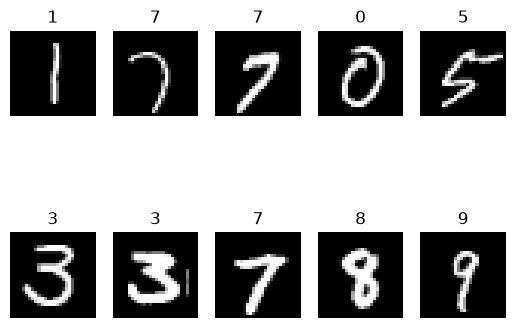

In [7]:
fig, axes = plt.subplots(2,5)
for i, ax in enumerate(axes.flat):
    ax.imshow(image[i].squeeze(), cmap = "gray")
    ax.set_title(label[i].item())
    ax.axis("off")

# Logistic Regression

Logistic regression is a supervised machine learning algorithm used for classification, predicting the probability of an event (e.g., yes/no) rather than continuous numbers. It models data using an S-shaped sigmoid function, mapping inputs to probabilities between 0 and 1.

In [9]:
# This model will take a 28 ×28-pixel image of handwritten digits as input 
# and classify them into one of the 10 output classes of digits 0 to 9.
class LogisticRegression (nn.Module):
    def __init__(self, n_inputs, n_outputs):
        # super().__init__(): Triggers the constructor of the parent class (nn.Module).
        # It sets up internal PyTorch registries necessary for tracking weights, biases, and submodules.
        super().__init__()
        #self.linear = nn.Linear(...): Registers a fully connected (dense) layer as an attribute of the class.
        # 28*28: Sets the input feature size to 784, matching the total pixels of a flattened 28 × 28 
        # 10: Sets the output size to 10, creating one raw score (logit) for each potential target class.
        self.linear = nn.Linear(n_inputs, n_outputs) 

    def forward(self,x):
        # The sigmoid function is an activation function that converts any real number into a value between 0 and 1.
        # self.linear(x) computes the raw score (logit).
        # torch.sigmoid(...) converts that score into a value between 0 and 1.
        # y_pred becomes a probability-like output that is well suited for binary classification.
        y_predict = torch.sigmoid(self.linear(x))
        return y_predict

In [11]:
# instantiate the model
n_inputs = 28*28 # makes a 1D vector of 784
n_outputs = 10
log_regr = LogisticRegression(n_inputs, n_outputs)

In [12]:
# defining the optimizer
# Uses Stochastic Gradient Descent (SGD).
# The learning rate (lr=0.001) controls how much the weights are updated during each optimization step.
optimizer = torch.optim.SGD(log_regr.parameters(), lr=0.001)
# defining Cross-Entropy loss
# This computes the difference between the predicted logits and the true class labels for multiclass classification.
criterion = torch.nn.CrossEntropyLoss()

In [13]:
epochs = 50
loss_total = []
accuracy_total = []
# Training loop
# Each batch contains 64 images and 64 labels
for epoch in range(epochs):
    for i, (images, labels) in enumerate(train_loader):
        # Prevents gradients from accumulating across batches.
        optimizer.zero_grad()
        # image.view(-1, 28*28) means flatten images. Changes the shape from 64×1×28×28 to 64×784 because a linear layer expects vectors as input.
    
        # Forward Pass 
        # Produces a prediction for each image in the batch.
        outputs = log_regr(images.view(-1, 28*28))

        # Compute Loss
        # Measures how far the predictions are from the true labels.
        loss = criterion(outputs, labels)

        # Backpropagation
        # Computes the gradients of the loss with respect to all trainable parameters.
        loss.backward()

        # Update Parameters
        # Uses the computed gradients to update the weights and biases.
        optimizer.step()
        
    loss_total.append(loss.item())
    correct = 0
    for images, labels in test_loader:
        outputs = log_regr(images.view(-1, 28*28))
        # Predict the Class
        # Suppose the model outputs [0.2, 1.5, -0.3, ..., 2.7] The largest value is at index 9, so the predicted digit is 9.
        _, predicted = torch.max(outputs.data,1)
        #print(predicted)
        # Count Correct Predictions
        # Adds the number of correct predictions in the current batch.
        correct += (predicted == labels).sum()
    # If the model correctly classifies 9,200 out of 10,000 test images, Accuracy = 92%
    accuracy = 100 * (correct.item())/len(test_dataset)
    accuracy_total.append(accuracy)
    print('Epoch: {}. Loss: {}. Accuracy: {}'.format(epoch, loss.item(), accuracy))


Epoch: 0. Loss: 2.260622978210449. Accuracy: 40.05
Epoch: 1. Loss: 2.1802239418029785. Accuracy: 62.9
Epoch: 2. Loss: 2.1575729846954346. Accuracy: 71.89
Epoch: 3. Loss: 2.1342287063598633. Accuracy: 74.86
Epoch: 4. Loss: 2.0735223293304443. Accuracy: 76.69
Epoch: 5. Loss: 2.037151336669922. Accuracy: 77.85
Epoch: 6. Loss: 2.0176212787628174. Accuracy: 79.19
Epoch: 7. Loss: 1.952490210533142. Accuracy: 79.9
Epoch: 8. Loss: 1.9695019721984863. Accuracy: 80.46
Epoch: 9. Loss: 1.9747023582458496. Accuracy: 81.01
Epoch: 10. Loss: 1.9164937734603882. Accuracy: 81.42
Epoch: 11. Loss: 1.916008710861206. Accuracy: 81.64
Epoch: 12. Loss: 1.9331629276275635. Accuracy: 81.9
Epoch: 13. Loss: 1.9075467586517334. Accuracy: 82.05
Epoch: 14. Loss: 1.8554444313049316. Accuracy: 82.19
Epoch: 15. Loss: 1.9280463457107544. Accuracy: 82.48
Epoch: 16. Loss: 1.8339502811431885. Accuracy: 82.59
Epoch: 17. Loss: 1.8157397508621216. Accuracy: 82.73
Epoch: 18. Loss: 1.8540866374969482. Accuracy: 82.86
Epoch: 19.

# Loss plot

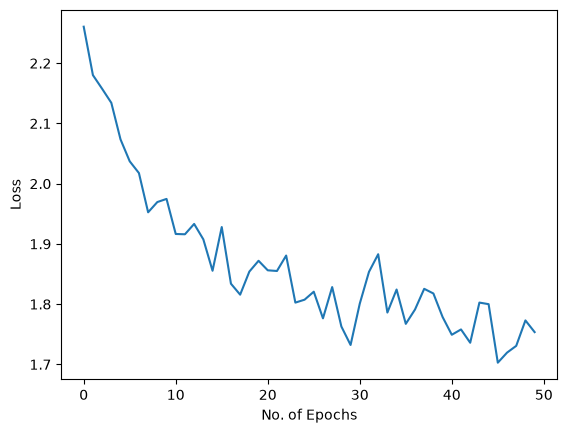

In [14]:
plt.plot(loss_total)
plt.xlabel("No. of Epochs")
plt.ylabel("Loss")
plt.show()

# Accuracy plot

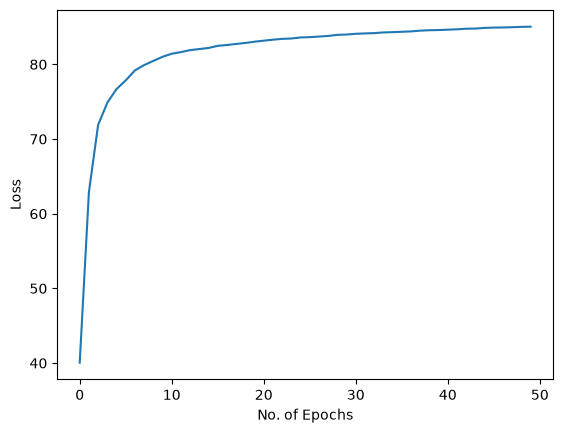

In [15]:
plt.plot(accuracy_total)
plt.xlabel("No. of Epochs")
plt.ylabel("Loss")
plt.show()

# Multi-Layer Perceptron (MLP) neural network

In [16]:
class MultilayerPerceptron (nn.Module):
    def __init__ (self):
        super(MultilayerPerceptron, self).__init__()

        self.network = nn.Sequential(
            # A fully connected layer that takes the 784 input features and projects them to 256 hidden features.
            # Input layer to hidden layer
            nn.Linear(784,128), 
            # Introduces non-linearity, allowing the network to learn complex patterns instead of just linear equations.
            nn.ReLU(),
            # Compresses the 256 features down to a tighter representation of 128 features.
            # Hidden layer 2
            #nn.Linear(256, 128),
            #nn.ReLU(),
            # Outputs 10 raw scores (logits). Each score corresponds to one of the 10 possible classes.
            # Hiden layer to output layer
            nn.Linear(128, 10)
        )

    def forward (self, x):
        return self.network(x)

In [17]:
# instantiate the model
MLP_model = MultilayerPerceptron()
print(MLP_model)

MultilayerPerceptron(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [18]:
optimizer = torch.optim.Adam(MLP_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [19]:
epochs = 15
loss_total = []
accuracy_total = []
# Training loop
# Each batch contains 64 images and 64 labels
for epoch in range(epochs):
    for i, (images, labels) in enumerate(train_loader):
        # Prevents gradients from accumulating across batches.
        optimizer.zero_grad()
        # image.view(-1, 28*28) means flatten images. Changes the shape from 64×1×28×28 to 64×784 because a linear layer expects vectors as input.
    
        # Forward Pass 
        # Produces a prediction for each image in the batch.
        outputs = MLP_model(images.view(-1, 28*28))

        # Compute Loss
        # Measures how far the predictions are from the true labels.
        loss = criterion(outputs, labels)

        # Backpropagation
        # Computes the gradients of the loss with respect to all trainable parameters.
        loss.backward()

        # Update Parameters
        # Uses the computed gradients to update the weights and biases.
        optimizer.step()
        
    loss_total.append(loss.item())
    correct = 0
    for images, labels in test_loader:
        outputs = MLP_model(images.view(-1, 28*28))
        # Predict the Class
        # Suppose the model outputs [0.2, 1.5, -0.3, ..., 2.7] The largest value is at index 9, so the predicted digit is 9.
        _, predicted = torch.max(outputs.data,1)
        #print(predicted)
        # Count Correct Predictions
        # Adds the number of correct predictions in the current batch.
        correct += (predicted == labels).sum()
    # If the model correctly classifies 9,200 out of 10,000 test images, Accuracy = 92%
    accuracy = 100 * (correct.item())/len(test_dataset)
    accuracy_total.append(accuracy)
    print('Epoch: {}. Loss: {}. Accuracy: {}'.format(epoch, loss.item(), accuracy))


Epoch: 0. Loss: 0.350130170583725. Accuracy: 94.57
Epoch: 1. Loss: 0.16475623846054077. Accuracy: 96.54
Epoch: 2. Loss: 0.03074752166867256. Accuracy: 96.77
Epoch: 3. Loss: 0.04838555306196213. Accuracy: 97.19
Epoch: 4. Loss: 0.012787092477083206. Accuracy: 97.51
Epoch: 5. Loss: 0.11341246217489243. Accuracy: 97.45
Epoch: 6. Loss: 0.004869184456765652. Accuracy: 97.57
Epoch: 7. Loss: 0.03683692216873169. Accuracy: 97.86
Epoch: 8. Loss: 0.10325048863887787. Accuracy: 97.85
Epoch: 9. Loss: 0.03416600450873375. Accuracy: 97.83
Epoch: 10. Loss: 0.021261349320411682. Accuracy: 97.83
Epoch: 11. Loss: 0.0032280362211167812. Accuracy: 97.7
Epoch: 12. Loss: 0.005271985661238432. Accuracy: 97.65
Epoch: 13. Loss: 0.00237992312759161. Accuracy: 97.94
Epoch: 14. Loss: 0.0010036469902843237. Accuracy: 97.89


# Loss plot

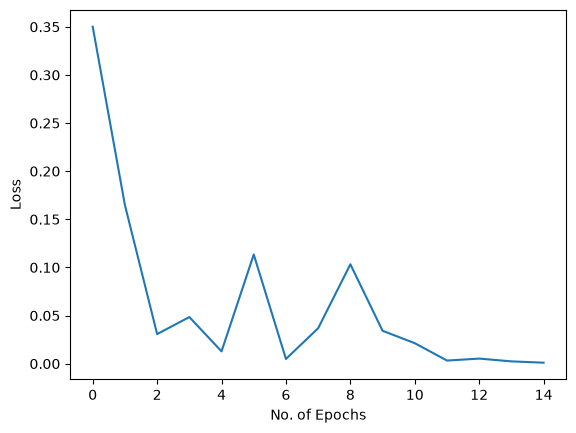

In [20]:
plt.plot(loss_total)
plt.xlabel("No. of Epochs")
plt.ylabel("Loss")
plt.show()

# Accuracy plot

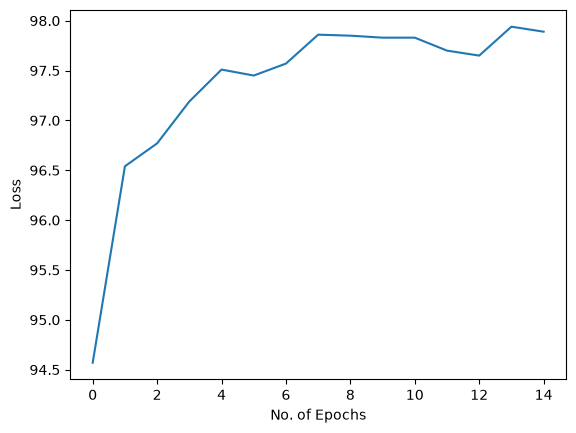

In [21]:
plt.plot(accuracy_total)
plt.xlabel("No. of Epochs")
plt.ylabel("Loss")
plt.show()

# CNN

In [20]:
class CNN (nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # 1st convolutional layer
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 2nd convolutional layer
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Fully connedted layer
            nn.Flatten(),
            nn.Linear(64 * 5 * 5, 128),
            #nn.ReLU(),
            nn.Softmax(dim=1),
            nn.Linear(128, 10)
        )
    
    def forward (self, x):
        x = self.features(x)
        return x

In [21]:
# instantiate the model
CNN_model = CNN()
print(CNN_model)

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=1600, out_features=128, bias=True)
    (8): Softmax(dim=1)
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [22]:
optimizer = torch.optim.Adam(CNN_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [23]:
epochs = 25
loss_total = []
accuracy_total = []
# Training loop
# Each batch contains 64 images and 64 labels
for epoch in range(epochs):
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        # Prevents gradients from accumulating across batches.
        optimizer.zero_grad()
        # image.view(-1, 28*28) means flatten images. Changes the shape from 64×1×28×28 to 64×784 because a linear layer expects vectors as input.
    
        # Forward Pass 
        # Produces a prediction for each image in the batch.
        outputs = CNN_model(images)

        # Compute Loss
        # Measures how far the predictions are from the true labels.
        loss = criterion(outputs, labels)

        # Backpropagation
        # Computes the gradients of the loss with respect to all trainable parameters.
        loss.backward()

        # Update Parameters
        # Uses the computed gradients to update the weights and biases.
        optimizer.step()
        
    loss_total.append(loss.item())
    correct = 0
    for images, labels in test_loader:
        outputs = CNN_model(images)
        # Predict the Class
        # Suppose the model outputs [0.2, 1.5, -0.3, ..., 2.7] The largest value is at index 9, so the predicted digit is 9.
        _, predicted = torch.max(outputs.data,1)
        #print(predicted)
        # Count Correct Predictions
        # Adds the number of correct predictions in the current batch.
        correct += (predicted == labels).sum()
    # If the model correctly classifies 9,200 out of 10,000 test images, Accuracy = 92%
    accuracy = 100 * (correct.item())/len(test_dataset)
    accuracy_total.append(accuracy)
    print('Epoch: {}. Loss: {}. Accuracy: {}'.format(epoch, loss.item(), accuracy))

Epoch: 0. Loss: 1.2387290000915527. Accuracy: 70.1
Epoch: 1. Loss: 0.8369972109794617. Accuracy: 70.5
Epoch: 2. Loss: 0.5164172649383545. Accuracy: 70.68
Epoch: 3. Loss: 0.5483030080795288. Accuracy: 70.54
Epoch: 4. Loss: 0.5937997102737427. Accuracy: 70.9
Epoch: 5. Loss: 0.4696289896965027. Accuracy: 70.75
Epoch: 6. Loss: 0.5637252926826477. Accuracy: 73.2
Epoch: 7. Loss: 0.42739951610565186. Accuracy: 71.17
Epoch: 8. Loss: 0.33131179213523865. Accuracy: 75.21
Epoch: 9. Loss: 0.2652166187763214. Accuracy: 96.44
Epoch: 10. Loss: 0.17270024120807648. Accuracy: 98.03
Epoch: 11. Loss: 0.09243100136518478. Accuracy: 98.2
Epoch: 12. Loss: 0.13294322788715363. Accuracy: 98.47
Epoch: 13. Loss: 0.048021234571933746. Accuracy: 98.5
Epoch: 14. Loss: 0.061165615916252136. Accuracy: 98.53
Epoch: 15. Loss: 0.025232410058379173. Accuracy: 98.64
Epoch: 16. Loss: 0.02611059695482254. Accuracy: 98.53
Epoch: 17. Loss: 0.01643599569797516. Accuracy: 98.6
Epoch: 18. Loss: 0.03474091738462448. Accuracy: 98

# Loss plot

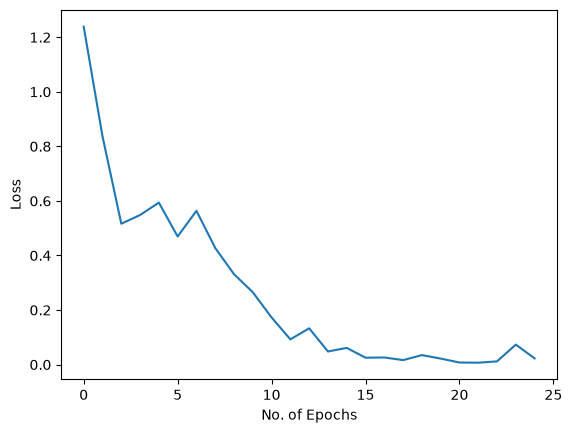

In [24]:
plt.plot(loss_total)
plt.xlabel("No. of Epochs")
plt.ylabel("Loss")
plt.show()

# Accuracy plot

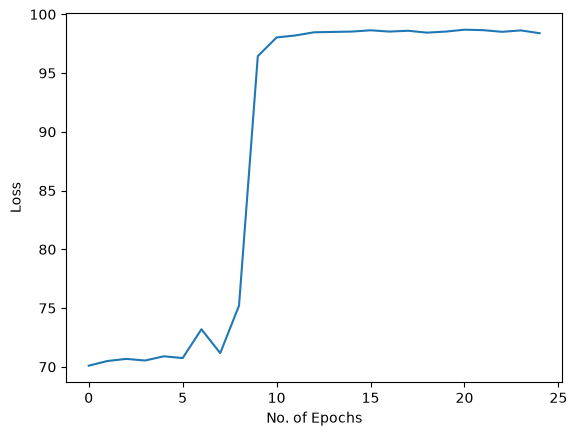

In [25]:
plt.plot(accuracy_total)
plt.xlabel("No. of Epochs")
plt.ylabel("Loss")
plt.show()

# Model Comparison

| Model               | Parameters | Accuracy |     Speed |
| ------------------- | ---------: | -------: | --------: |
| Logistic Regression |      ~7.8K |   85%    | Very Fast |
| MLP                 |      ~235K |   97%    |      Fast |
| CNN                 |      ~420K |   99%    |      Slow |